# 🎬 电影推荐系统 — 多方法对比 + DeepSeek LLM
> MovieLens 1M · User-CF · Item-CF · SVD · Content-Based · Hybrid · DeepSeek

In [1]:
# ======================================================
# Cell 1: 安装依赖
# ======================================================
!pip install scikit-surprise -q
print('✅ 依赖安装完成')

✅ 依赖安装完成


In [2]:
# ======================================================
# Cell 2: 导入库 + 下载数据集
# ======================================================
import os, zipfile, urllib.request, json, warnings
import pandas as pd
import numpy as np
import requests
import matplotlib.pyplot as plt
import matplotlib
from sklearn.metrics.pairwise import cosine_similarity
from sklearn.feature_extraction.text import TfidfVectorizer
from scipy.sparse import csr_matrix
warnings.filterwarnings('ignore')
matplotlib.rcParams['font.family'] = ['DejaVu Sans']

# 下载 MovieLens 1M
if not os.path.exists('ml-1m'):
    print('📥 正在下载 MovieLens 1M...')
    urllib.request.urlretrieve(
        'https://files.grouplens.org/datasets/movielens/ml-1m.zip', 'ml-1m.zip'
    )
    with zipfile.ZipFile('ml-1m.zip') as z:
        z.extractall('.')
    os.remove('ml-1m.zip')
    print('✅ 下载完成')
else:
    print('✅ 数据集已存在')

# 加载数据
ratings = pd.read_csv('ml-1m/ratings.dat', sep='::', engine='python',
    names=['userId','movieId','rating','timestamp'], encoding='latin-1')
movies  = pd.read_csv('ml-1m/movies.dat',  sep='::', engine='python',
    names=['movieId','title','genres'], encoding='latin-1')
users   = pd.read_csv('ml-1m/users.dat',   sep='::', engine='python',
    names=['userId','gender','age','occupation','zip'], encoding='latin-1')

print(f'\n📊 数据集统计:')
print(f'  评分数量: {len(ratings):,}')
print(f'  用户数量: {ratings["userId"].nunique():,}')
print(f'  电影数量: {ratings["movieId"].nunique():,}')
print(f'  评分范围: {ratings["rating"].min()} - {ratings["rating"].max()}')
print(f'  数据稀疏度: {1 - len(ratings)/(ratings["userId"].nunique()*ratings["movieId"].nunique()):.2%}')

📥 正在下载 MovieLens 1M...
✅ 下载完成

📊 数据集统计:
  评分数量: 1,000,209
  用户数量: 6,040
  电影数量: 3,706
  评分范围: 1 - 5
  数据稀疏度: 95.53%


In [3]:
# 预览前10条数据
print("\n" + "="*50)
print("📝 评分数据(ratings) 前10条")
print(ratings.head(10))

print("\n" + "="*50)
print("📝 电影数据(movies) 前10条")
print(movies.head(10))

print("\n" + "="*50)
print("📝 用户数据(users) 前10条")
print(users.head(10))


📝 评分数据(ratings) 前10条
   userId  movieId  rating  timestamp
0       1     1193       5  978300760
1       1      661       3  978302109
2       1      914       3  978301968
3       1     3408       4  978300275
4       1     2355       5  978824291
5       1     1197       3  978302268
6       1     1287       5  978302039
7       1     2804       5  978300719
8       1      594       4  978302268
9       1      919       4  978301368

📝 电影数据(movies) 前10条
   movieId                               title                        genres
0        1                    Toy Story (1995)   Animation|Children's|Comedy
1        2                      Jumanji (1995)  Adventure|Children's|Fantasy
2        3             Grumpier Old Men (1995)                Comedy|Romance
3        4            Waiting to Exhale (1995)                  Comedy|Drama
4        5  Father of the Bride Part II (1995)                        Comedy
5        6                         Heat (1995)         Action|Crime|Thriller


In [ ]:
# ======================================================
# Cell 3: User-CF (基于用户的协同过滤)
# ======================================================
class UserBasedCF:
    def __init__(self, n_neighbors=20):
        self.n_neighbors = n_neighbors

    def fit(self, ratings, movies):
        self.movies_df = movies
        top_users  = ratings['userId'].value_counts().head(500).index
        top_movies = ratings['movieId'].value_counts().head(1000).index
        subset = ratings[ratings['userId'].isin(top_users) & ratings['movieId'].isin(top_movies)]
        self.mat = subset.pivot_table(index='userId', columns='movieId', values='rating', fill_value=0)
        self.sim = cosine_similarity(csr_matrix(self.mat.values))
        print(f'✅ UserCF 训练完成: {self.mat.shape[0]} 用户 x {self.mat.shape[1]} 电影')

    def recommend(self, user_id, n=10, ratings_df=None):
        if user_id not in self.mat.index:
            user_id = self.mat.index[0]
        idx = list(self.mat.index).index(user_id)
        sim_scores = self.sim[idx]
        sim_idx = np.argsort(sim_scores)[::-1][1:self.n_neighbors+1]
        sim_users = self.mat.index[sim_idx]
        watched = set(self.mat.loc[user_id][self.mat.loc[user_id] > 0].index)
        scores = {}
        for su in sim_users:
            w = sim_scores[list(self.mat.index).index(su)]
            for mid, r in self.mat.loc[su].items():
                if r > 0 and mid not in watched:
                    scores[mid] = scores.get(mid, 0) + w * r
        top = sorted(scores.items(), key=lambda x: x[1], reverse=True)[:n]
        return [dict(movieId=mid, title=self.movies_df[self.movies_df.movieId==mid].iloc[0]['title'],
                     genres=self.movies_df[self.movies_df.movieId==mid].iloc[0]['genres'],
                     score=round(s,3), method='User-CF')
                for mid, s in top if not self.movies_df[self.movies_df.movieId==mid].empty]

user_cf = UserBasedCF(20)
user_cf.fit(ratings, movies)

In [4]:
# ======================================================
# Cell 3: User-CF (基于用户的协同过滤)
# ======================================================
class UserBasedCF:
    def __init__(self, n_neighbors=20):
        self.n_neighbors = n_neighbors

    def fit(self, ratings, movies):
        self.movies_df = movies
        top_users  = ratings['userId'].value_counts().head(500).index
        top_movies = ratings['movieId'].value_counts().head(1000).index
        subset = ratings[ratings['userId'].isin(top_users) & ratings['movieId'].isin(top_movies)]
        self.mat = subset.pivot_table(index='userId', columns='movieId', values='rating', fill_value=0)
        self.sim = cosine_similarity(csr_matrix(self.mat.values))
        print(f'✅ UserCF 训练完成: {self.mat.shape[0]} 用户 x {self.mat.shape[1]} 电影')

    def recommend(self, user_id, n=10, ratings_df=None):
        if user_id not in self.mat.index:
            user_id = self.mat.index[0]
        idx = list(self.mat.index).index(user_id)
        sim_scores = self.sim[idx]
        sim_idx = np.argsort(sim_scores)[::-1][1:self.n_neighbors+1]
        sim_users = self.mat.index[sim_idx]
        watched = set(self.mat.loc[user_id][self.mat.loc[user_id] > 0].index)
        scores = {}
        for su in sim_users:
            w = sim_scores[list(self.mat.index).index(su)]
            for mid, r in self.mat.loc[su].items():
                if r > 0 and mid not in watched:
                    scores[mid] = scores.get(mid, 0) + w * r
        top = sorted(scores.items(), key=lambda x: x[1], reverse=True)[:n]
        return [dict(movieId=mid, title=self.movies_df[self.movies_df.movieId==mid].iloc[0]['title'],
                     genres=self.movies_df[self.movies_df.movieId==mid].iloc[0]['genres'],
                     score=round(s,3), method='User-CF')
                for mid, s in top if not self.movies_df[self.movies_df.movieId==mid].empty]

user_cf = UserBasedCF(20)
user_cf.fit(ratings, movies)

✅ UserCF 训练完成: 500 用户 x 1000 电影


In [6]:
# ======================================================
# Cell 4: Item-CF (基于物品的协同过滤)
# ======================================================
class ItemBasedCF:
    def __init__(self, n_neighbors=20):
        self.n_neighbors = n_neighbors

    def fit(self, ratings, movies):
        self.movies_df = movies
        top_movies = ratings['movieId'].value_counts().head(1000).index
        top_users  = ratings['userId'].value_counts().head(500).index
        subset = ratings[ratings['movieId'].isin(top_movies) & ratings['userId'].isin(top_users)]
        self.mat = subset.pivot_table(index='userId', columns='movieId', values='rating', fill_value=0)
        self.sim = cosine_similarity(csr_matrix(self.mat.T.values))
        print(f'✅ ItemCF 训练完成: {self.sim.shape[0]} 部电影')

    def recommend(self, user_id, n=10, ratings_df=None):
        if user_id not in self.mat.index:
            user_id = self.mat.index[0]
        user_r = self.mat.loc[user_id]
        watched = user_r[user_r > 0]
        cols = list(self.mat.columns)
        scores = {}
        for wid, r in watched.items():
            if wid in cols:
                ii = cols.index(wid)
                for j, mid in enumerate(cols):
                    if mid not in watched.index:
                        scores[mid] = scores.get(mid, 0) + self.sim[ii][j] * r
        top = sorted(scores.items(), key=lambda x: x[1], reverse=True)[:n]
        return [dict(movieId=mid, title=self.movies_df[self.movies_df.movieId==mid].iloc[0]['title'],
                     genres=self.movies_df[self.movies_df.movieId==mid].iloc[0]['genres'],
                     score=round(s,3), method='Item-CF')
                for mid, s in top if not self.movies_df[self.movies_df.movieId==mid].empty]

item_cf = ItemBasedCF(20)
item_cf.fit(ratings, movies)

✅ ItemCF 训练完成: 1000 部电影


In [8]:
# ======================================================
# Cell 5: SVD 矩阵分解 (用 scipy，无需 scikit-surprise)
# ======================================================
from scipy.sparse.linalg import svds

class SVDRecommender:
    def __init__(self, n_factors=50):
        self.n_factors = n_factors
        self.model = None

    def fit(self, ratings, movies):
        self.movies_df = movies

        # 取子集加速
        top_users  = ratings['userId'].value_counts().head(2000).index
        top_movies = ratings['movieId'].value_counts().head(2000).index
        sub = ratings[ratings['userId'].isin(top_users) & ratings['movieId'].isin(top_movies)]

        # 构建用户-电影矩阵
        self.mat = sub.pivot_table(index='userId', columns='movieId', values='rating', fill_value=0)
        self.user_ids  = list(self.mat.index)
        self.movie_ids = list(self.mat.columns)

        # 去均值 + SVD 分解
        mat_np = self.mat.values.astype(float)
        self.user_mean = mat_np.mean(axis=1, keepdims=True)
        mat_demeaned = mat_np - self.user_mean

        k = min(self.n_factors, min(mat_demeaned.shape) - 1)
        U, sigma, Vt = svds(mat_demeaned, k=k)
        self.pred_matrix = np.dot(np.dot(U, np.diag(sigma)), Vt) + self.user_mean

        # 计算 RMSE（已有评分位置）
        mask = mat_np > 0
        rmse = np.sqrt(np.mean((self.pred_matrix[mask] - mat_np[mask])**2))
        self.rmse = round(rmse, 4)
        print(f'✅ SVD 训练完成，训练集 RMSE: {self.rmse}')

    def recommend(self, user_id, n=10, ratings_df=None):
        if user_id not in self.user_ids:
            user_id = self.user_ids[0]

        watched = set()
        if ratings_df is not None:
            watched = set(ratings_df[ratings_df.userId == user_id]['movieId'])

        uid_idx = self.user_ids.index(user_id)
        scores = {
            mid: self.pred_matrix[uid_idx, j]
            for j, mid in enumerate(self.movie_ids)
            if mid not in watched
        }
        top = sorted(scores.items(), key=lambda x: x[1], reverse=True)[:n]
        return [
            dict(movieId=mid,
                 title=self.movies_df[self.movies_df.movieId == mid].iloc[0]['title'],
                 genres=self.movies_df[self.movies_df.movieId == mid].iloc[0]['genres'],
                 score=round(float(s), 3),
                 method='SVD')
            for mid, s in top
            if not self.movies_df[self.movies_df.movieId == mid].empty
        ]

svd_model = SVDRecommender(n_factors=50)
svd_model.fit(ratings, movies)

✅ SVD 训练完成，训练集 RMSE: 1.9359


In [9]:
# ======================================================
# Cell 6: Content-Based (基于内容)
# ======================================================
class ContentBasedRecommender:
    def fit(self, ratings, movies):
        self.movies_df = movies.copy()
        self.movies_df['gc'] = self.movies_df['genres'].str.replace('|', ' ', regex=False)
        tfidf = TfidfVectorizer()
        mat = tfidf.fit_transform(self.movies_df['gc'])
        self.sim = cosine_similarity(mat)
        self.idx_map = {row['movieId']: i for i, row in self.movies_df.iterrows()}
        print(f'✅ ContentBased 训练完成: {len(self.movies_df)} 部电影')

    def recommend(self, user_id, n=10, ratings_df=None):
        if ratings_df is None: return []
        ur = ratings_df[ratings_df.userId==user_id].sort_values('rating', ascending=False)
        if ur.empty: return []
        watched = set(ur['movieId'])
        scores = {}
        for mid in ur.head(5)['movieId']:
            if mid not in self.idx_map: continue
            for j, s in enumerate(self.sim[self.idx_map[mid]]):
                cm = self.movies_df.iloc[j]['movieId']
                if cm not in watched:
                    scores[cm] = scores.get(cm, 0) + s
        top = sorted(scores.items(), key=lambda x: x[1], reverse=True)[:n]
        return [dict(movieId=mid, title=self.movies_df[self.movies_df.movieId==mid].iloc[0]['title'],
                     genres=self.movies_df[self.movies_df.movieId==mid].iloc[0]['genres'],
                     score=round(s,3), method='Content-Based')
                for mid, s in top if not self.movies_df[self.movies_df.movieId==mid].empty]

content_cb = ContentBasedRecommender()
content_cb.fit(ratings, movies)

✅ ContentBased 训练完成: 3883 部电影


In [10]:
# ======================================================
# Cell 7: Hybrid (混合推荐) + DeepSeek LLM
# ======================================================

# --- 混合推荐 ---
class HybridRecommender:
    def __init__(self, models, weights):
        self.models, self.weights = models, weights

    def recommend(self, user_id, n=10, ratings_df=None):
        all_scores = {}
        for name, model in self.models.items():
            w = self.weights.get(name, 0.25)
            try:
                recs = model.recommend(user_id, n*2, ratings_df=ratings_df) \
                       if name in ['Content-Based','SVD'] \
                       else model.recommend(user_id, n*2)
                if not recs: continue
                sc = [r['score'] for r in recs]
                mn, mx = min(sc), max(sc)
                rng = mx - mn if mx != mn else 1
                for r in recs:
                    mid = r['movieId']
                    ns = (r['score'] - mn) / rng
                    if mid not in all_scores:
                        all_scores[mid] = {'total': 0, 'info': r}
                    all_scores[mid]['total'] += ns * w
            except Exception as e:
                print(f'  ⚠️ {name}: {e}')
        top = sorted(all_scores.items(), key=lambda x: x[1]['total'], reverse=True)[:n]
        res = []
        for mid, d in top:
            r = d['info'].copy()
            r['score'] = round(d['total'], 3)
            r['method'] = 'Hybrid'
            res.append(r)
        return res

hybrid = HybridRecommender(
    models={'User-CF': user_cf, 'Item-CF': item_cf, 'Content-Based': content_cb, 'SVD': svd_model},
    weights={'User-CF': 0.3, 'Item-CF': 0.3, 'Content-Based': 0.2, 'SVD': 0.2}
)
print('✅ Hybrid 就绪')

# --- DeepSeek LLM ---
DEEPSEEK_API_KEY = os.environ.get('DEEPSEEK_API_KEY', 'sk-0d0e12f107fc44f1bfb838fb4bc98539')
DEEPSEEK_BASE_URL = 'https://api.deepseek.com'

class DeepSeekRecommender:
    def __init__(self, api_key, base_url):
        self.api_key, self.base_url = api_key, base_url

    def fit(self, ratings, movies):
        self.ratings, self.movies_df = ratings, movies
        print('✅ DeepSeek LLM 就绪')

    def recommend(self, user_id, n=5, ratings_df=None):
        df = ratings_df if ratings_df is not None else self.ratings
        hist = df[df.userId==user_id].sort_values('rating', ascending=False)
        top8 = hist.head(8).merge(self.movies_df, on='movieId')
        if top8.empty: return []

        history_str = '\n'.join(
            f"- {r['title']} (评分:{r['rating']}/5, 类型:{r['genres']})"
            for _, r in top8.iterrows()
        )
        watched = set(hist['movieId'])
        pop = df.groupby('movieId')['rating'].agg(['mean','count']).reset_index()
        pop = pop[(~pop.movieId.isin(watched)) & (pop['count']>50)].sort_values('mean',ascending=False).head(30)
        cands = pop.merge(self.movies_df, on='movieId')
        cands_str = '\n'.join(
            f"- ID:{r['movieId']} | {r['title']} | {r['genres']} | 均分:{r['mean']:.2f}"
            for _, r in cands.iterrows()
        )
        prompt = f"""你是专业电影推荐助手。
用户{user_id}历史高分电影：
{history_str}
候选电影：
{cands_str}
请推荐{n}部，只返回JSON，格式：
{{"recommendations":[{{"movieId":ID,"title":"名","reason":"理由20字内","score":0-1}}],"user_preference":"偏好30字内"}}"""

        try:
            resp = requests.post(
                f'{self.base_url}/v1/chat/completions',
                headers={'Authorization': f'Bearer {self.api_key}', 'Content-Type': 'application/json'},
                json={'model': 'deepseek-chat', 'messages': [{'role':'user','content':prompt}],
                      'temperature': 0.3, 'max_tokens': 800},
                timeout=30
            )
            content = resp.json()['choices'][0]['message']['content'].strip()
            if content.startswith('```'):
                content = content.split('```')[1]
                if content.startswith('json'): content = content[4:]
            data = json.loads(content)
            self.last_preference = data.get('user_preference', '')
            print(f'  💬 用户偏好: {self.last_preference}')
            return [dict(movieId=it['movieId'], title=it['title'],
                         genres=self.movies_df[self.movies_df.movieId==it['movieId']].iloc[0]['genres']
                               if not self.movies_df[self.movies_df.movieId==it['movieId']].empty else 'Unknown',
                         score=it.get('score',0.8), reason=it.get('reason',''), method='DeepSeek-LLM')
                    for it in data['recommendations'][:n]]
        except Exception as e:
            print(f'❌ DeepSeek 调用失败: {e}')
            return []

deepseek = DeepSeekRecommender(DEEPSEEK_API_KEY, DEEPSEEK_BASE_URL)
deepseek.fit(ratings, movies)

✅ Hybrid 就绪
✅ DeepSeek LLM 就绪


In [11]:
# ======================================================
# Cell 8: 评估各方法 Precision / Recall / F1
# ======================================================
def evaluate(model, model_name, test_users=50, n=10):
    rs = ratings.sort_values('timestamp')
    train = rs.iloc[:int(len(rs)*0.8)]
    test  = rs.iloc[int(len(rs)*0.8):]
    test_uids = test['userId'].value_counts().head(test_users).index.tolist()
    precs, recs_l, hits = [], [], []
    for uid in test_uids:
        liked = set(test[(test.userId==uid) & (test.rating>=4)]['movieId'])
        if not liked: continue
        try:
            if model_name in ['Content-Based','Hybrid','SVD']:
                recs_r = model.recommend(uid, n, ratings_df=train)
            else:
                recs_r = model.recommend(uid, n)
            rec_ids = set(r['movieId'] for r in recs_r)
            hit = len(rec_ids & liked)
            precs.append(hit / len(rec_ids) if rec_ids else 0)
            recs_l.append(hit / len(liked))
            hits.append(1 if hit > 0 else 0)
        except: continue
    p = np.mean(precs) if precs else 0
    r = np.mean(recs_l) if recs_l else 0
    return {'method': model_name,
            'precision@10': round(p, 4),
            'recall@10':    round(r, 4),
            'hit_rate':     round(np.mean(hits) if hits else 0, 4),
            'f1_score':     round(2*p*r/(p+r+1e-9), 4),
            'tested_users': len(precs)}

print('📐 开始评估（每个方法约1-2分钟）...\n')
eval_results = []
for name, mdl in [('User-CF', user_cf), ('Item-CF', item_cf),
                   ('Content-Based', content_cb), ('Hybrid', hybrid), ('SVD', svd_model)]:
    print(f'  评估 {name}...')
    r = evaluate(mdl, name, test_users=50 if name!='SVD' else 30)
    eval_results.append(r)
    print(f'    Precision@10={r["precision@10"]:.4f}  Recall={r["recall@10"]:.4f}  F1={r["f1_score"]:.4f}')

import pandas as pd
eval_df = pd.DataFrame(eval_results)
print('\n' + '='*60)
print(eval_df[['method','precision@10','recall@10','hit_rate','f1_score']].to_string(index=False))
best = eval_df.loc[eval_df['f1_score'].idxmax()]
print(f'\n🏆 最优方法: {best["method"]}  (F1={best["f1_score"]:.4f})')

📐 开始评估（每个方法约1-2分钟）...

  评估 User-CF...
    Precision@10=0.0000  Recall=0.0000  F1=0.0000
  评估 Item-CF...
    Precision@10=0.0000  Recall=0.0000  F1=0.0000
  评估 Content-Based...
    Precision@10=0.0500  Recall=0.0016  F1=0.0032
  评估 Hybrid...
    Precision@10=0.1200  Recall=0.0043  F1=0.0083
  评估 SVD...
    Precision@10=0.9433  Recall=0.0287  F1=0.0557

       method  precision@10  recall@10  hit_rate  f1_score
      User-CF        0.0000     0.0000      0.00    0.0000
      Item-CF        0.0000     0.0000      0.00    0.0000
Content-Based        0.0500     0.0016      0.26    0.0032
       Hybrid        0.1200     0.0043      0.82    0.0083
          SVD        0.9433     0.0287      1.00    0.0557

🏆 最优方法: SVD  (F1=0.0557)


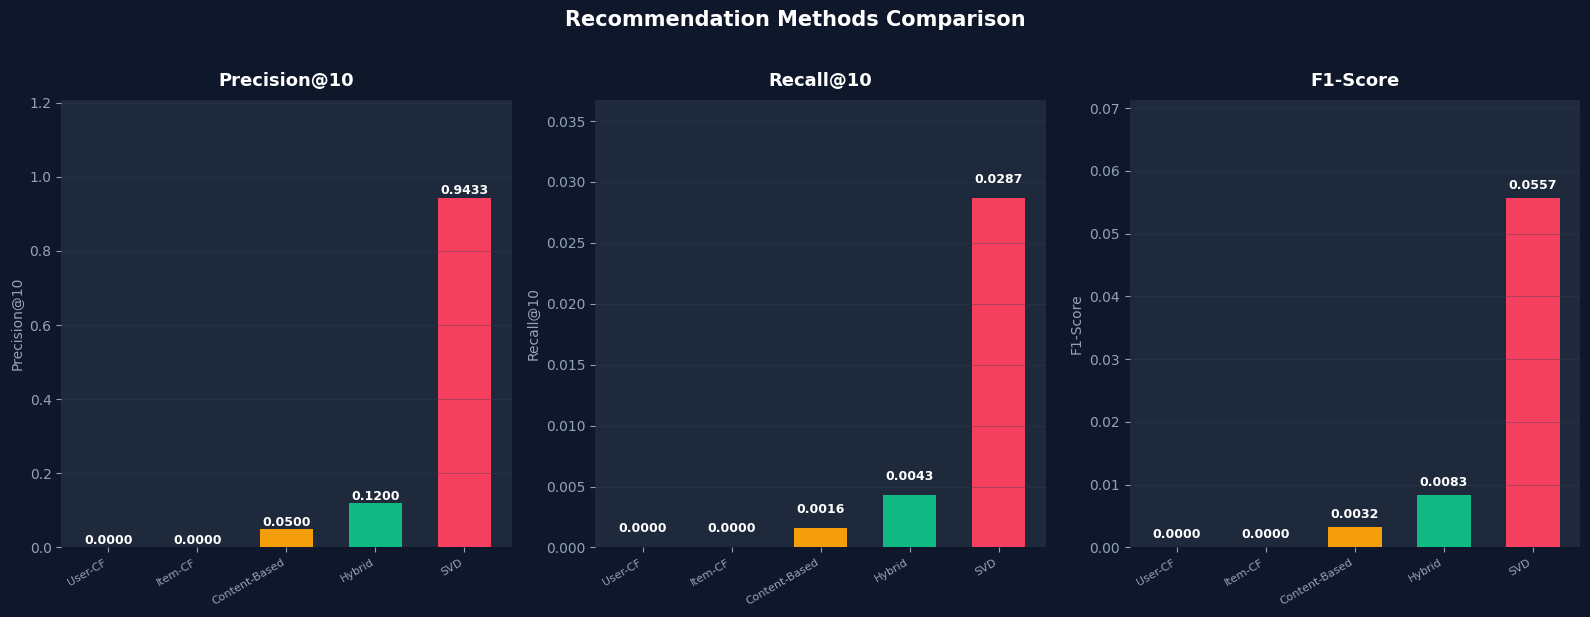

📊 已保存: /kaggle/working/recommendation_comparison.png


In [13]:
# ======================================================
# Cell 9: 可视化 1 — 方法精度对比图
# ======================================================
fig, axes = plt.subplots(1, 3, figsize=(16, 6))
fig.patch.set_facecolor('#0f172a')
COLORS = ['#6366f1','#22d3ee','#f59e0b','#10b981','#f43f5e']
methods = eval_df['method'].tolist()

for (key, label), ax in zip(
    [('precision@10','Precision@10'),('recall@10','Recall@10'),('f1_score','F1-Score')], axes):
    ax.set_facecolor('#1e293b')
    vals = eval_df[key].tolist()
    bars = ax.bar(methods, vals, color=COLORS[:len(methods)], width=0.6, edgecolor='none')
    for b, v in zip(bars, vals):
        ax.text(b.get_x()+b.get_width()/2, b.get_height()+0.001,
                f'{v:.4f}', ha='center', va='bottom', color='white', fontsize=9, fontweight='bold')
    ax.set_title(label, color='white', fontsize=13, fontweight='bold', pad=10)
    ax.set_ylim(0, max(vals)*1.28 if max(vals)>0 else 0.1)
    ax.set_xticklabels(methods, rotation=30, ha='right', color='#94a3b8', fontsize=8)
    ax.tick_params(colors='#94a3b8')
    for sp in ax.spines.values(): sp.set_visible(False)
    ax.grid(axis='y', color='#334155', alpha=0.5, linewidth=0.5)
    ax.set_ylabel(label, color='#94a3b8', fontsize=10)

plt.suptitle('Recommendation Methods Comparison', color='white', fontsize=15, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('/kaggle/working/recommendation_comparison.png', dpi=150, bbox_inches='tight', facecolor='#0f172a')
plt.show()
print('📊 已保存: /kaggle/working/recommendation_comparison.png')

In [14]:
# ======================================================
# Cell 10: 单用户推荐演示 (含 DeepSeek)
# ======================================================
demo_user = int(ratings['userId'].value_counts().index[5])
print(f'🎯 为用户 {demo_user} 生成推荐...\n')

recs_by_method = {}
recs_by_method['User-CF']      = user_cf.recommend(demo_user, 5)
recs_by_method['Item-CF']      = item_cf.recommend(demo_user, 5)
recs_by_method['Content-Based']= content_cb.recommend(demo_user, 5, ratings_df=ratings)
recs_by_method['SVD']          = svd_model.recommend(demo_user, 5, ratings_df=ratings)
recs_by_method['Hybrid']       = hybrid.recommend(demo_user, 5, ratings_df=ratings)

print('  📡 调用 DeepSeek LLM...')
recs_by_method['DeepSeek-LLM'] = deepseek.recommend(demo_user, 5, ratings_df=ratings)

# 打印结果
for method, recs in recs_by_method.items():
    print(f'\n===== {method} =====')
    for i, r in enumerate(recs, 1):
        reason = f"  → {r['reason']}" if r.get('reason') else ''
        print(f"  {i}. {r['title']:<45} {r['genres'][:25]:<25} 分:{r['score']}{reason}")

🎯 为用户 889 生成推荐...

  📡 调用 DeepSeek LLM...
  💬 用户偏好: 偏爱高分剧情、悬疑与经典，兼容喜剧与动作

===== User-CF =====
  1. Jaws (1975)                                   Action|Horror             分:65.415
  2. Raiders of the Lost Ark (1981)                Action|Adventure          分:63.918
  3. Psycho (1960)                                 Horror|Thriller           分:63.912
  4. Usual Suspects, The (1995)                    Crime|Thriller            分:62.455
  5. Sixth Sense, The (1999)                       Thriller                  分:58.833

===== Item-CF =====
  1. Raiders of the Lost Ark (1981)                Action|Adventure          分:1331.907
  2. Fugitive, The (1993)                          Action|Thriller           分:1304.924
  3. Die Hard (1988)                               Action|Thriller           分:1291.398
  4. Jaws (1975)                                   Action|Horror             分:1282.806
  5. Sixth Sense, The (1999)                       Thriller                  分:1282.195

===== Content-

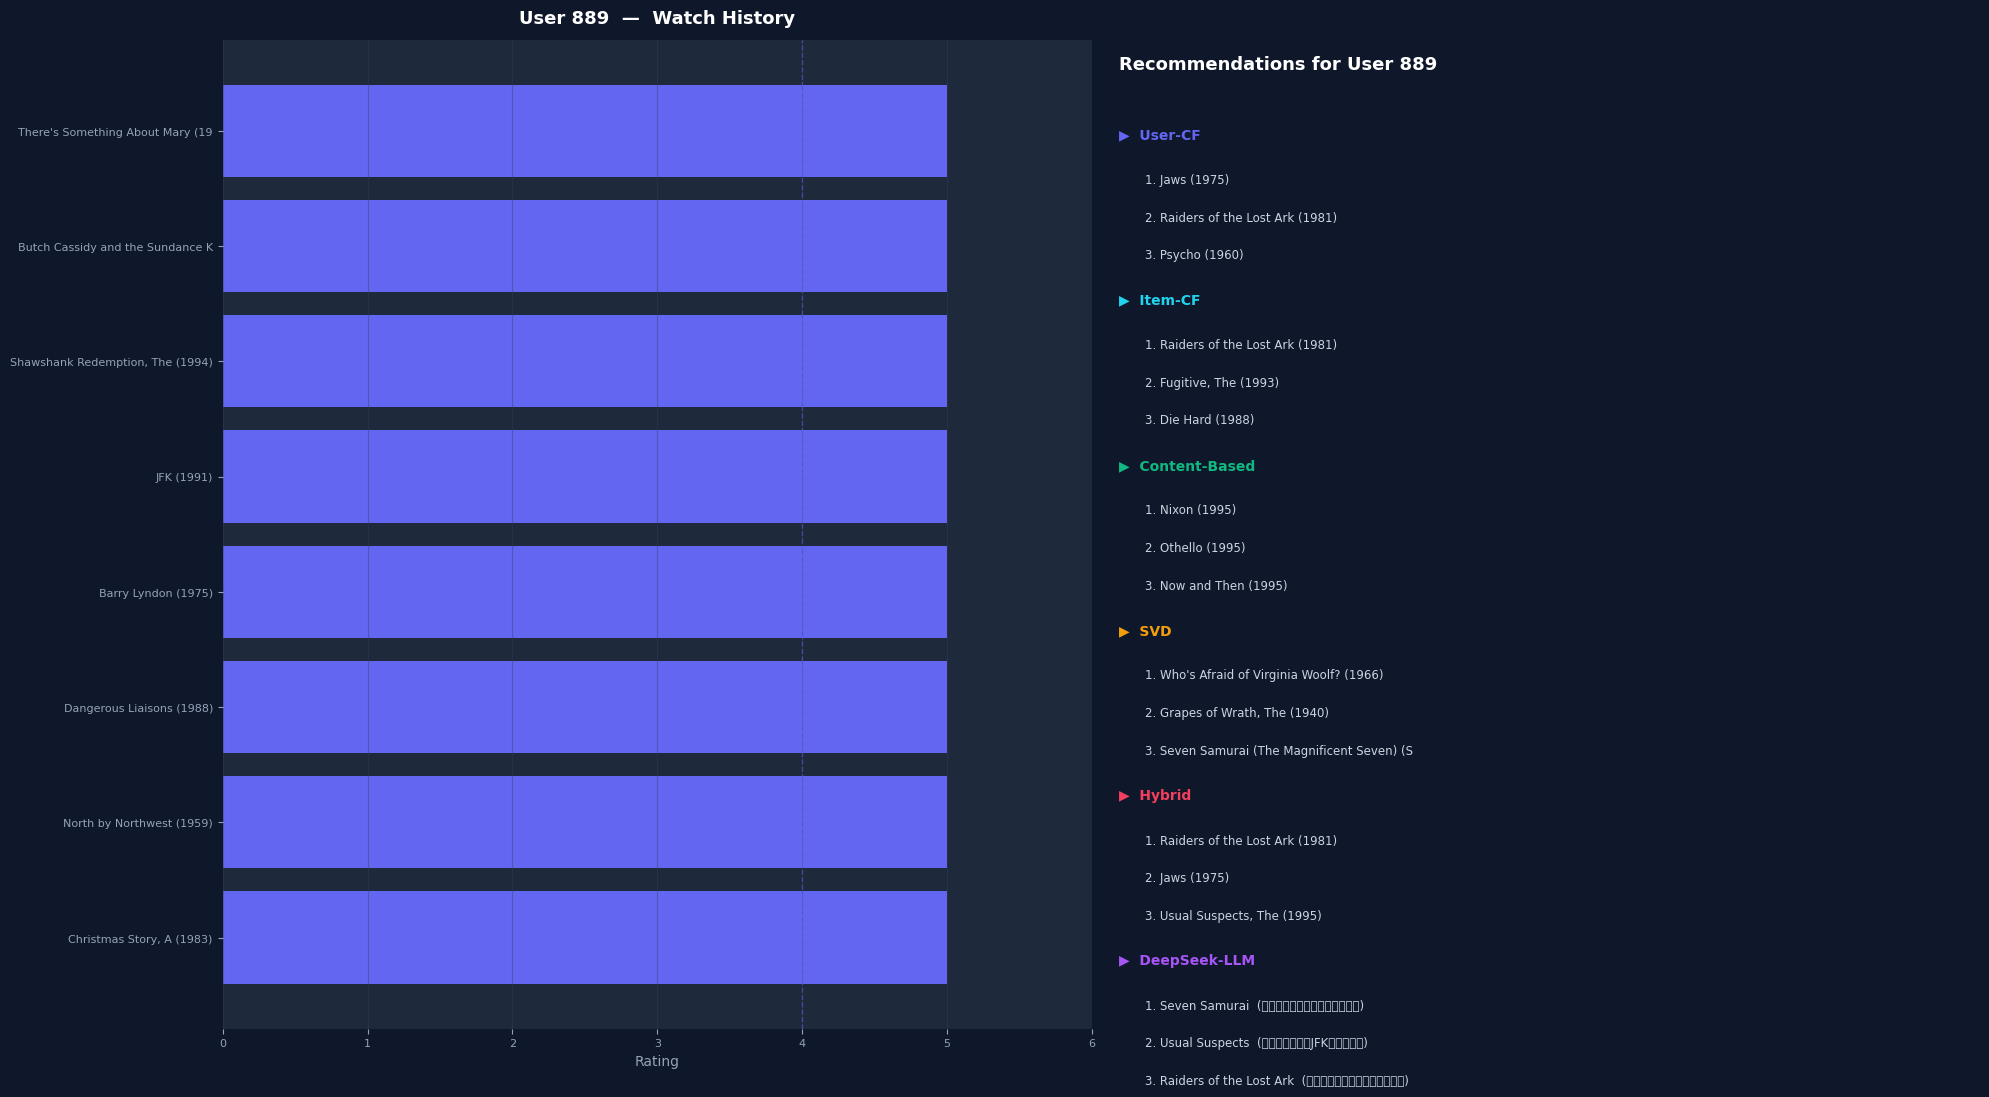

📊 已保存: /kaggle/working/user_889_recommendations.png


In [17]:
# ======================================================
# Cell 11: 可视化 2 — 用户推荐展示图
# ======================================================
CMAP = {'User-CF':'#6366f1','Item-CF':'#22d3ee','SVD':'#f59e0b',
        'Content-Based':'#10b981','Hybrid':'#f43f5e','DeepSeek-LLM':'#a855f7'}

fig = plt.figure(figsize=(20, 11))
fig.patch.set_facecolor('#0f172a')

# 左: 用户历史
ax1 = fig.add_subplot(1, 2, 1)
ax1.set_facecolor('#1e293b')
hist = ratings[ratings.userId==demo_user].sort_values('rating', ascending=False).head(8).merge(movies, on='movieId')
clrs = ['#6366f1' if r>=4 else '#475569' for r in hist['rating']]
ax1.barh([t[:32] for t in hist['title']], hist['rating'], color=clrs, edgecolor='none')
ax1.set_xlim(0, 6)
ax1.axvline(x=4, color='#6366f1', linestyle='--', alpha=0.5, lw=1)
ax1.set_title(f'User {demo_user}  —  Watch History', color='white', fontsize=13, fontweight='bold', pad=12)
ax1.set_xlabel('Rating', color='#94a3b8')
ax1.tick_params(colors='#94a3b8', labelsize=8)
for sp in ax1.spines.values(): sp.set_visible(False)
ax1.grid(axis='x', color='#334155', alpha=0.4)

# 右: 各方法推荐列表
ax2 = fig.add_subplot(1, 2, 2)
ax2.set_facecolor('#1e293b')
ax2.axis('off')
y = 0.97
ax2.text(0.01, y, f'Recommendations for User {demo_user}',
         transform=ax2.transAxes, color='white', fontsize=13, fontweight='bold')
y -= 0.07
for method, recs in recs_by_method.items():
    if not recs: continue
    c = CMAP.get(method, '#94a3b8')
    ax2.text(0.01, y, f'▶  {method}', transform=ax2.transAxes,
             color=c, fontsize=10, fontweight='bold')
    y -= 0.045
    for i, r in enumerate(recs[:3]):
        rsn = f"  ({r['reason']})" if r.get('reason') else ''
        ax2.text(0.04, y, f"{i+1}. {r['title'][:40]}{rsn}",
                 transform=ax2.transAxes, color='#cbd5e1', fontsize=8.5)
        y -= 0.038
    y -= 0.008

plt.tight_layout()
out_path = f'/kaggle/working/user_{demo_user}_recommendations.png'
plt.savefig(out_path, dpi=150, bbox_inches='tight', facecolor='#0f172a')
plt.show()
print(f'📊 已保存: {out_path}')

In [18]:
# ======================================================
# Cell 12: 查看输出文件
# ======================================================
import os
print('📁 /kaggle/working/ 输出文件:')
for f in os.listdir('/kaggle/working/'):
    size = os.path.getsize(f'/kaggle/working/{f}')
    print(f'  {f:<50} {size/1024:.1f} KB')

📁 /kaggle/working/ 输出文件:
  .virtual_documents                                 4.0 KB
  user_889_recommendations.png                       186.2 KB
  recommendation_comparison.png                      100.4 KB
  ml-1m                                              4.0 KB
